<a href="https://colab.research.google.com/github/geetha-487/churn_prediction.ipynb/blob/main/Churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane scikit-learn pandas numpy matplotlib seaborn shap lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 79.7 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=024c0103c39e7364b26a99992c30c3c62e8ad967e68a91568edbb68ba2974916
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import shap

print("All libraries imported successfully.")

All libraries imported successfully.


In [30]:
df = pd.read_csv(
    "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


In [31]:
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [32]:
print("Columns:")
print(df.columns.tolist())

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [33]:
print("Dataset Information")
print("===================")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset Information
Rows: 7043
Columns: 21

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows:
0


In [34]:
df = df.drop("customerID", axis=1)

print("Customer ID removed.")
print("New shape:", df.shape)

Customer ID removed.
New shape: (7043, 20)


In [35]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("TotalCharges converted to numeric.")

TotalCharges converted to numeric.


In [36]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [37]:
df = df.dropna()

print("Missing rows removed.")
print("New dataset shape:", df.shape)

Missing rows removed.
New dataset shape: (7032, 20)


In [38]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["Churn"].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [39]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Input features:", X.shape)
print("Target:", y.shape)

Input features: (7032, 19)
Target: (7032,)


In [40]:
X = pd.get_dummies(
    X,
    drop_first=True
)

print("Categorical variables encoded.")
print("Total features:", X.shape[1])

Categorical variables encoded.
Total features: 30


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 5625
Testing samples: 1407


In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [43]:
correlations = X_train.copy()

correlations["Churn"] = y_train.values

correlation_values = (
    correlations.corr()["Churn"]
    .drop("Churn")
    .abs()
    .sort_values(ascending=False)
)

print("Top features related to churn:")
display(correlation_values.head(10))

Top features related to churn:


,Churn
tenure,0.351710
InternetService_Fiber optic,0.306416
PaymentMethod_Electronic check,0.305342
Contract_Two year,0.301801
InternetService_No,0.227420
OnlineSecurity_No internet service,0.227420
DeviceProtection_No internet service,0.227420
TechSupport_No internet service,0.227420
StreamingMovies_No internet service,0.227420
StreamingTV_No internet service,0.227420


In [44]:
quantum_features = correlation_values.head(4).index.tolist()

print("Selected quantum features:")
for i, feature in enumerate(quantum_features, 1):
    print(f"{i}. {feature}")

Selected quantum features:
1. tenure
2. InternetService_Fiber optic
3. PaymentMethod_Electronic check
4. Contract_Two year


In [45]:
X_train_quantum = X_train[quantum_features].copy()
X_test_quantum = X_test[quantum_features].copy()

quantum_scaler = StandardScaler()

X_train_quantum = quantum_scaler.fit_transform(
    X_train_quantum
)

X_test_quantum = quantum_scaler.transform(
    X_test_quantum
)

print("Quantum training shape:", X_train_quantum.shape)
print("Quantum testing shape:", X_test_quantum.shape)

Quantum training shape: (5625, 4)
Quantum testing shape: (1407, 4)


In [46]:
n_qubits = 4

dev = qml.device(
    "default.qubit",
    wires=n_qubits
)

print("Quantum device created.")
print("Number of qubits:", n_qubits)

Quantum device created.
Number of qubits: 4


In [47]:
@qml.qnode(dev)
def quantum_circuit(inputs, weights):

    # Encode classical features
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Trainable quantum layer
    for i in range(n_qubits):
        qml.RY(weights[i], wires=i)
        qml.RZ(weights[i], wires=i)

    # Entangle qubits
    for i in range(n_qubits - 1):
        qml.CNOT(
            wires=[i, i + 1]
        )

    # Measure first qubit
    return qml.expval(
        qml.PauliZ(0)
    )

print("Variational Quantum Circuit created.")

Variational Quantum Circuit created.


In [51]:
np.random.seed(42)

weights = qml.numpy.array(
    np.random.randn(n_qubits),
    requires_grad=True
)

print("Initial quantum weights:")
print(weights)

Initial quantum weights:
[ 0.49671415 -0.1382643   0.64768854  1.52302986]


In [52]:
sample = X_train_quantum[0]

output = quantum_circuit(
    sample,
    weights
)

print("Quantum circuit output:", output)

Quantum circuit output: -0.24520789758732853


In [53]:
def quantum_probability(
    inputs,
    weights
):

    output = quantum_circuit(
        inputs,
        weights
    )

    probability = (
        output + 1
    ) / 2

    return probability

In [54]:
def loss_function(
    weights,
    X,
    y
):

    predictions = []

    for sample in X:

        predictions.append(
            quantum_probability(
                sample,
                weights
            )
        )

    predictions = qml.math.stack(
        predictions
    )

    predictions = qml.math.clip(
        predictions,
        1e-7,
        1 - 1e-7
    )

    loss = -qml.math.mean(
        y * qml.math.log(predictions)
        +
        (1 - y) *
        qml.math.log(1 - predictions)
    )

    return loss

In [55]:
optimizer = qml.AdamOptimizer(
    stepsize=0.05
)

print("Classical optimizer created.")

Classical optimizer created.


In [59]:
# Use a smaller training subset for faster quantum simulation

train_samples = 500

X_train_vqc = X_train_quantum[:train_samples]
y_train_vqc = y_train.values[:train_samples]

print("Quantum training samples:", len(X_train_vqc))

Quantum training samples: 500


In [60]:
epochs = 10

loss_history = []

for epoch in range(epochs):

    weights, current_loss = optimizer.step_and_cost(
        lambda w: loss_function(
            w,
            X_train_vqc,
            y_train_vqc
        ),
        weights
    )

    loss_history.append(float(current_loss))

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {current_loss:.4f}"
    )

Epoch 1/10 - Loss: 1.7497
Epoch 2/10 - Loss: 1.7451
Epoch 3/10 - Loss: 1.7698
Epoch 4/10 - Loss: 1.7467
Epoch 5/10 - Loss: 1.7554
Epoch 6/10 - Loss: 1.7749
Epoch 7/10 - Loss: 1.8709
Epoch 8/10 - Loss: 1.7611
Epoch 9/10 - Loss: 1.7698
Epoch 10/10 - Loss: 1.7468


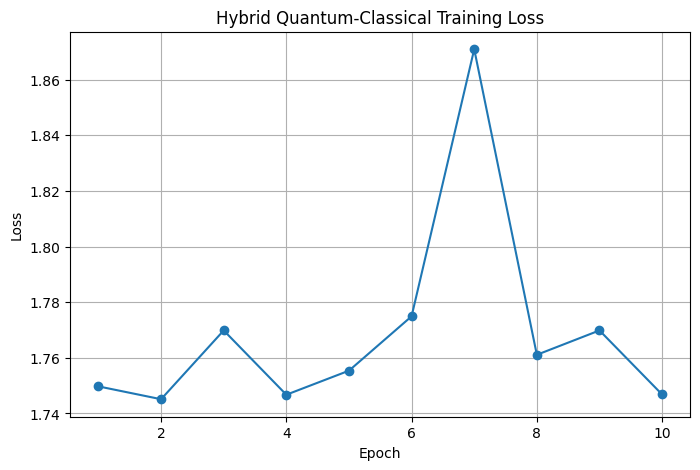

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Hybrid Quantum-Classical Training Loss"
)

plt.grid(True)
plt.show()

In [62]:
def predict_quantum(
    X,
    weights
):

    predictions = []

    for sample in X:

        probability = quantum_probability(
            sample,
            weights
        )

        predictions.append(
            float(probability)
        )

    return np.array(predictions)

In [63]:
y_prob = predict_quantum(
    X_test_quantum,
    weights
)

y_pred = (
    y_prob >= 0.5
).astype(int)

print("Test predictions generated.")

Test predictions generated.


In [64]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("====================================")
print("HYBRID QUANTUM-CLASSICAL VQC")
print("====================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

HYBRID QUANTUM-CLASSICAL VQC
Accuracy : 0.4520
Precision: 0.3207
Recall   : 0.9492
F1 Score : 0.4794
ROC-AUC  : 0.6294


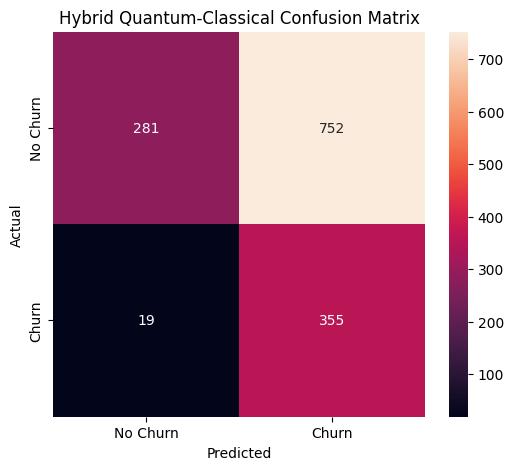

In [65]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Hybrid Quantum-Classical Confusion Matrix"
)

plt.show()

In [66]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.94      0.27      0.42      1033
       Churn       0.32      0.95      0.48       374

    accuracy                           0.45      1407
   macro avg       0.63      0.61      0.45      1407
weighted avg       0.77      0.45      0.44      1407



In [67]:
prediction_results = pd.DataFrame({

    "Actual Churn": y_test.values,

    "Churn Probability":
        np.round(
            y_prob,
            4
        ),

    "Prediction": y_pred
})

display(
    prediction_results.head(10)
)

,Actual Churn,Churn Probability,Prediction
0,0,0.4821,0
1,0,0.9358,1
2,0,0.5836,1
3,1,0.8772,1
4,0,0.2495,0
5,1,0.4618,0
6,0,0.9270,1
7,0,0.9358,1
8,1,0.9872,1
9,0,0.2321,0


In [68]:
def quantum_model_for_xai(X):

    X = np.asarray(X)

    probabilities = []

    for sample in X:

        probability = quantum_probability(
            sample,
            weights
        )

        probabilities.append(
            float(probability)
        )

    return np.array(probabilities)

In [69]:
background_data = X_train_quantum[:50]

explainer = shap.Explainer(
    quantum_model_for_xai,
    background_data
)

shap_values = explainer(
    X_test_quantum[:50]
)

print("SHAP explanation generated.")

ExactExplainer explainer: 51it [02:36,  3.13s/it]

SHAP explanation generated.


/tmp/ipykernel_2704/2678697213.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


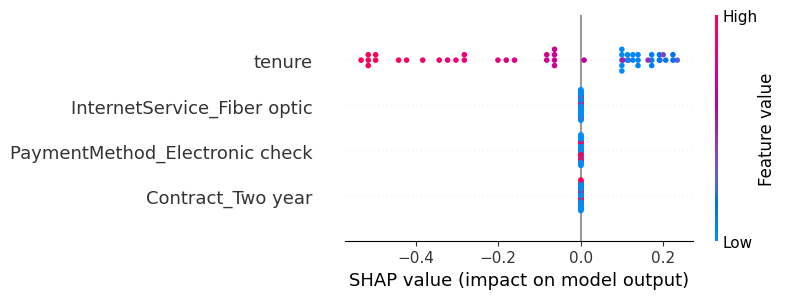

In [70]:
shap.summary_plot(
    shap_values,
    X_test_quantum[:50],
    feature_names=quantum_features
)

In [71]:
customer_index = 0

customer_probability = (
    y_prob[customer_index]
)

customer_prediction = (
    y_pred[customer_index]
)

print("================================")
print("CUSTOMER CHURN EXPLANATION")
print("================================")

print(
    "Churn Probability:",
    round(
        customer_probability * 100,
        2
    ),
    "%"
)

if customer_prediction == 1:
    print(
        "Prediction: WILL CHURN"
    )
else:
    print(
        "Prediction: WILL NOT CHURN"
    )

CUSTOMER CHURN EXPLANATION
Churn Probability: 48.21 %
Prediction: WILL NOT CHURN


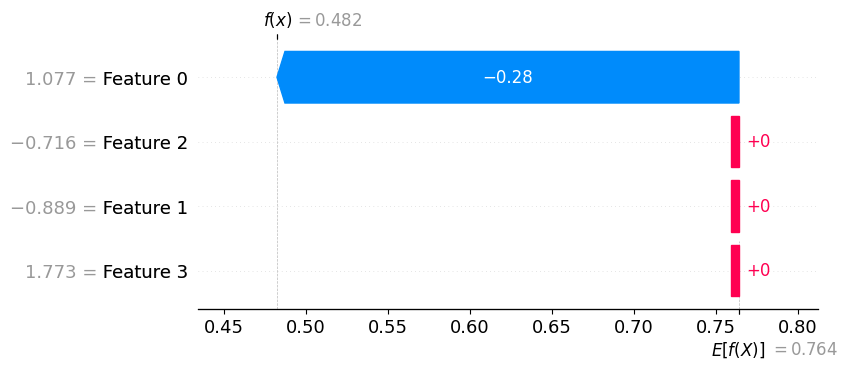

In [72]:
shap.plots.waterfall(
    shap_values[customer_index],
    max_display=4
)

In [73]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Hybrid VQC": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

final_results["Hybrid VQC"] = (
    final_results["Hybrid VQC"]
    .round(4)
)

display(final_results)

,Metric,Hybrid VQC
0,Accuracy,0.4520
1,Precision,0.3207
2,Recall,0.9492
3,F1 Score,0.4794
4,ROC-AUC,0.6294


In [74]:
final_results.to_csv(
    "hybrid_vqc_results.csv",
    index=False
)

prediction_results.to_csv(
    "churn_predictions.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
